Vietnam stock price prediction
### Updated to use both Open and Close prices as features

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, GRU
import copy

In [2]:
# Load data from csv file
data_appl = pd.read_csv('VNM-VNINDEX-History.csv')

In [3]:
# Show some first data samples
data_appl.head()

,Unnamed: 0,Open,High,Low,Close,Volume,TradingDate
0,0,2565.0,2565.0,2565.0,2565.0,109350,2006-01-19
1,1,2662.0,2662.0,2614.0,2614.0,157840,2006-01-20
2,2,2614.0,2614.0,2541.0,2541.0,81400,2006-01-23
3,3,2541.0,2541.0,2517.0,2517.0,66000,2006-01-24
4,4,2517.0,2565.0,2517.0,2565.0,57220,2006-01-25


In [4]:
# Get some info about the data
data_appl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4264 entries, 0 to 4263
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4264 non-null   int64  
 1   Open         4264 non-null   float64
 2   High         4264 non-null   float64
 3   Low          4264 non-null   float64
 4   Close        4264 non-null   float64
 5   Volume       4264 non-null   int64  
 6   TradingDate  4264 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 233.3+ KB


In [5]:
df = data_appl
X_data = []
y_data = []
window_size = 30  ### Split the dataset into time windows to get data samples.

In [6]:
open_col = df.columns.get_loc('Open')  #finding the position (index) of the 'Open' column inside dataset => return 2
close_col = df.columns.get_loc('Close')

In [7]:
# Time window for data feature (size of 'number of days').

# Number of features: Open (col index 2) and Close (col index 4)

open_col = df.columns.get_loc('Open')  #finding the position (index) of the 'Open' column inside dataset => return 2
close_col = df.columns.get_loc('Close')
n_features = 2  # Open + Close

for i in range(1, len(df) - window_size - 1):   #avoid going pass the dataset if we take one window at a time, each iteration creates one training example
    data_feature = []

    # Get a window_size time frame for data features (Open and Close)
    for j in range(window_size):
        open_price  = df.iloc[i + j, open_col]  #i as starting position of the window while j as offset inside the window (0 → 29)
        close_price = df.iloc[i + j, close_col] #We are extracting open/close price features for corresponding data
        data_feature.append([open_price, close_price])  #store as data feature

    # Label: next day's Open price
    data_label = [df.iloc[i + window_size, open_col]]

    # Append new data sample (feature and label) to X_data and y_data
    X_data.append(np.array(data_feature).reshape(window_size, n_features))
    #Convert data_feature (30 pairs open_close price) into Numpy array then reshape to (30, 2)
    y_data.append(np.array(data_label))
    #Convert labels into numpy array, shape becomes (1,)

In [8]:
### Split the data into training, validation and test set

# Split data into train, val and test. Note that 'shuffle=False' due to time-series data.
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, shuffle=False)
X_train, X_val, y_train, y_val   = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

In [9]:
# Convert from lists to Numpy arrays for reshaping purpose
X_train = np.array(X_train)
X_val   = np.array(X_val)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

# Reshape to (samples, window_size, n_features=2)
X_train = X_train.reshape(X_train.shape[0], window_size, n_features)
X_val   = X_val.reshape(X_val.shape[0],   window_size, n_features)
X_test  = X_test.reshape(X_test.shape[0],  window_size, n_features)

In [10]:
# Print shape of the training, validation and test set
print("Shape of training set: ",   X_train.shape)
print("Shape of validation set: ", X_val.shape)
print("Shape of test set: ",       X_test.shape)

Shape of training set:  (2708, 30, 2)
Shape of validation set:  (677, 30, 2)
Shape of test set:  (847, 30, 2)


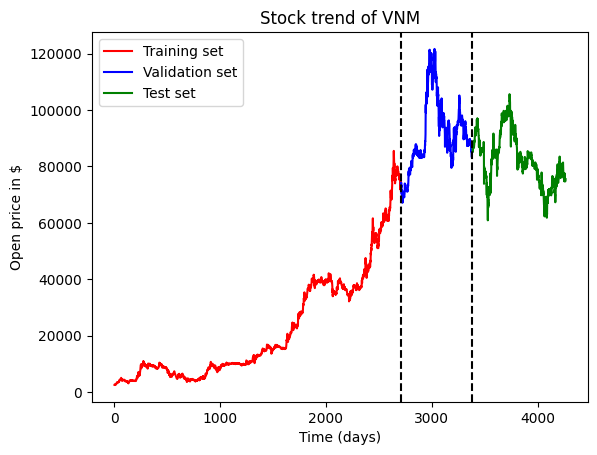

In [11]:
# Visualize the training, validation and test set
df_plot = df['Open']
df_plot = df_plot.reset_index(drop=False)

# Get lengths of the three subsets
size_train = X_train.shape[0]
size_val   = X_val.shape[0]
size_test  = X_test.shape[0]

# Plot the subset splits
ax = df_plot.iloc[:size_train, 1:2].plot(y=0, color='red',   label='Training set')
df_plot.iloc[size_train:size_train+size_val, 1:2].plot(y=0, color='blue',  label='Validation set', ax=ax)
df_plot.iloc[size_train+size_val:df_plot.shape[0], 1:2].plot(y=0, color='green', label='Test set', ax=ax)
ax.set_title("Stock trend of VNM")
plt.xlabel('Time (days)')
plt.ylabel('Open price in $')
plt.axvline(x=size_train,           color='black', linestyle='--')
plt.axvline(x=size_train+size_val,  color='black', linestyle='--')
plt.show()

In [12]:
# MinMax normalize the training data per sample across all features.
# We compute min/max over the entire feature window (both Open and Close values)
# so that both columns are scaled to the same [0, 1] range within each sample.

def minmax_normalize(X, y):
    X_norm = X.copy().astype(float)  #Makes float copies of X and y so the originals aren't modified
    y_norm = y.copy().astype(float)
    mins, maxs = [], []
    for i in range(len(X)):
        min_val = np.min(X[i]) #For each sample, finds the min and max price across its entire  window - i as window number
        max_val = np.max(X[i])
        X_norm[i] = (X[i] - min_val) / (max_val - min_val) #normalize X with min/max within window
        y_norm[i] = (y[i] - min_val) / (max_val - min_val)
        mins.append(min_val) #Save each window's min and max so we can reverse the normalization later
        maxs.append(max_val)
    return X_norm, y_norm, np.array(mins), np.array(maxs)

In [13]:
X_train_norm, y_train_norm, _, _           = minmax_normalize(X_train, y_train) #the mins/maxs for train and val aren't needed
X_val_norm,   y_val_norm,   _, _           = minmax_normalize(X_val,   y_val)
X_test_norm,  y_test_norm,  test_mins, test_maxs = minmax_normalize(X_test, y_test)

In [14]:
print("Shape of training set X: ",   X_train_norm.shape)
print("Shape of training set y: ", y_train_norm.shape)

Shape of training set X:  (2708, 30, 2)
Shape of training set y:  (2708, 1)


In [15]:
### Create and train the model

# Build the model architecture
# input_shape is (window_size, n_features) = (30, 2)
model = tf.keras.Sequential()
model.add(Conv1D(64,  kernel_size=3, activation='relu', input_shape=(window_size, n_features), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Conv1D(64,  kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(1))  # Output: next day's Open price (linear activation)

# Compile and train the model with Mean Squared Error loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mse'])
history = model.fit(X_train_norm, y_train_norm,
                    validation_data=(X_val_norm, y_val_norm),
                    epochs=30, batch_size=218)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step - loss: 0.9075 - mse: 0.9075 - val_loss: 0.1306 - val_mse: 0.1306
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1307 - mse: 0.1307 - val_loss: 0.1207 - val_mse: 0.1207
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1084 - mse: 0.1084 - val_loss: 0.1063 - val_mse: 0.1063
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0862 - mse: 0.0862 - val_loss: 0.0827 - val_mse: 0.0827
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0588 - mse: 0.0588 - val_loss: 0.0549 - val_mse: 0.0549
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0415 - mse: 0.0415 - val_loss: 0.0295 - val_mse: 0.0295
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0244 - mse: 0.0244 - val_loss: 0.0124 - val_mse: 0.0124
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0151 - mse: 0.0151 - val_loss: 0.0089 - val_mse: 0.0089
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0123 - ms

In [16]:
# Get prediction on the test data (normalized)
y_pred_norm = model.predict(X_test_norm)
print("MSE on the test set (normalized): ", mean_squared_error(y_pred_norm, y_test_norm))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
MSE on the test set (normalized):  0.005321800341149039


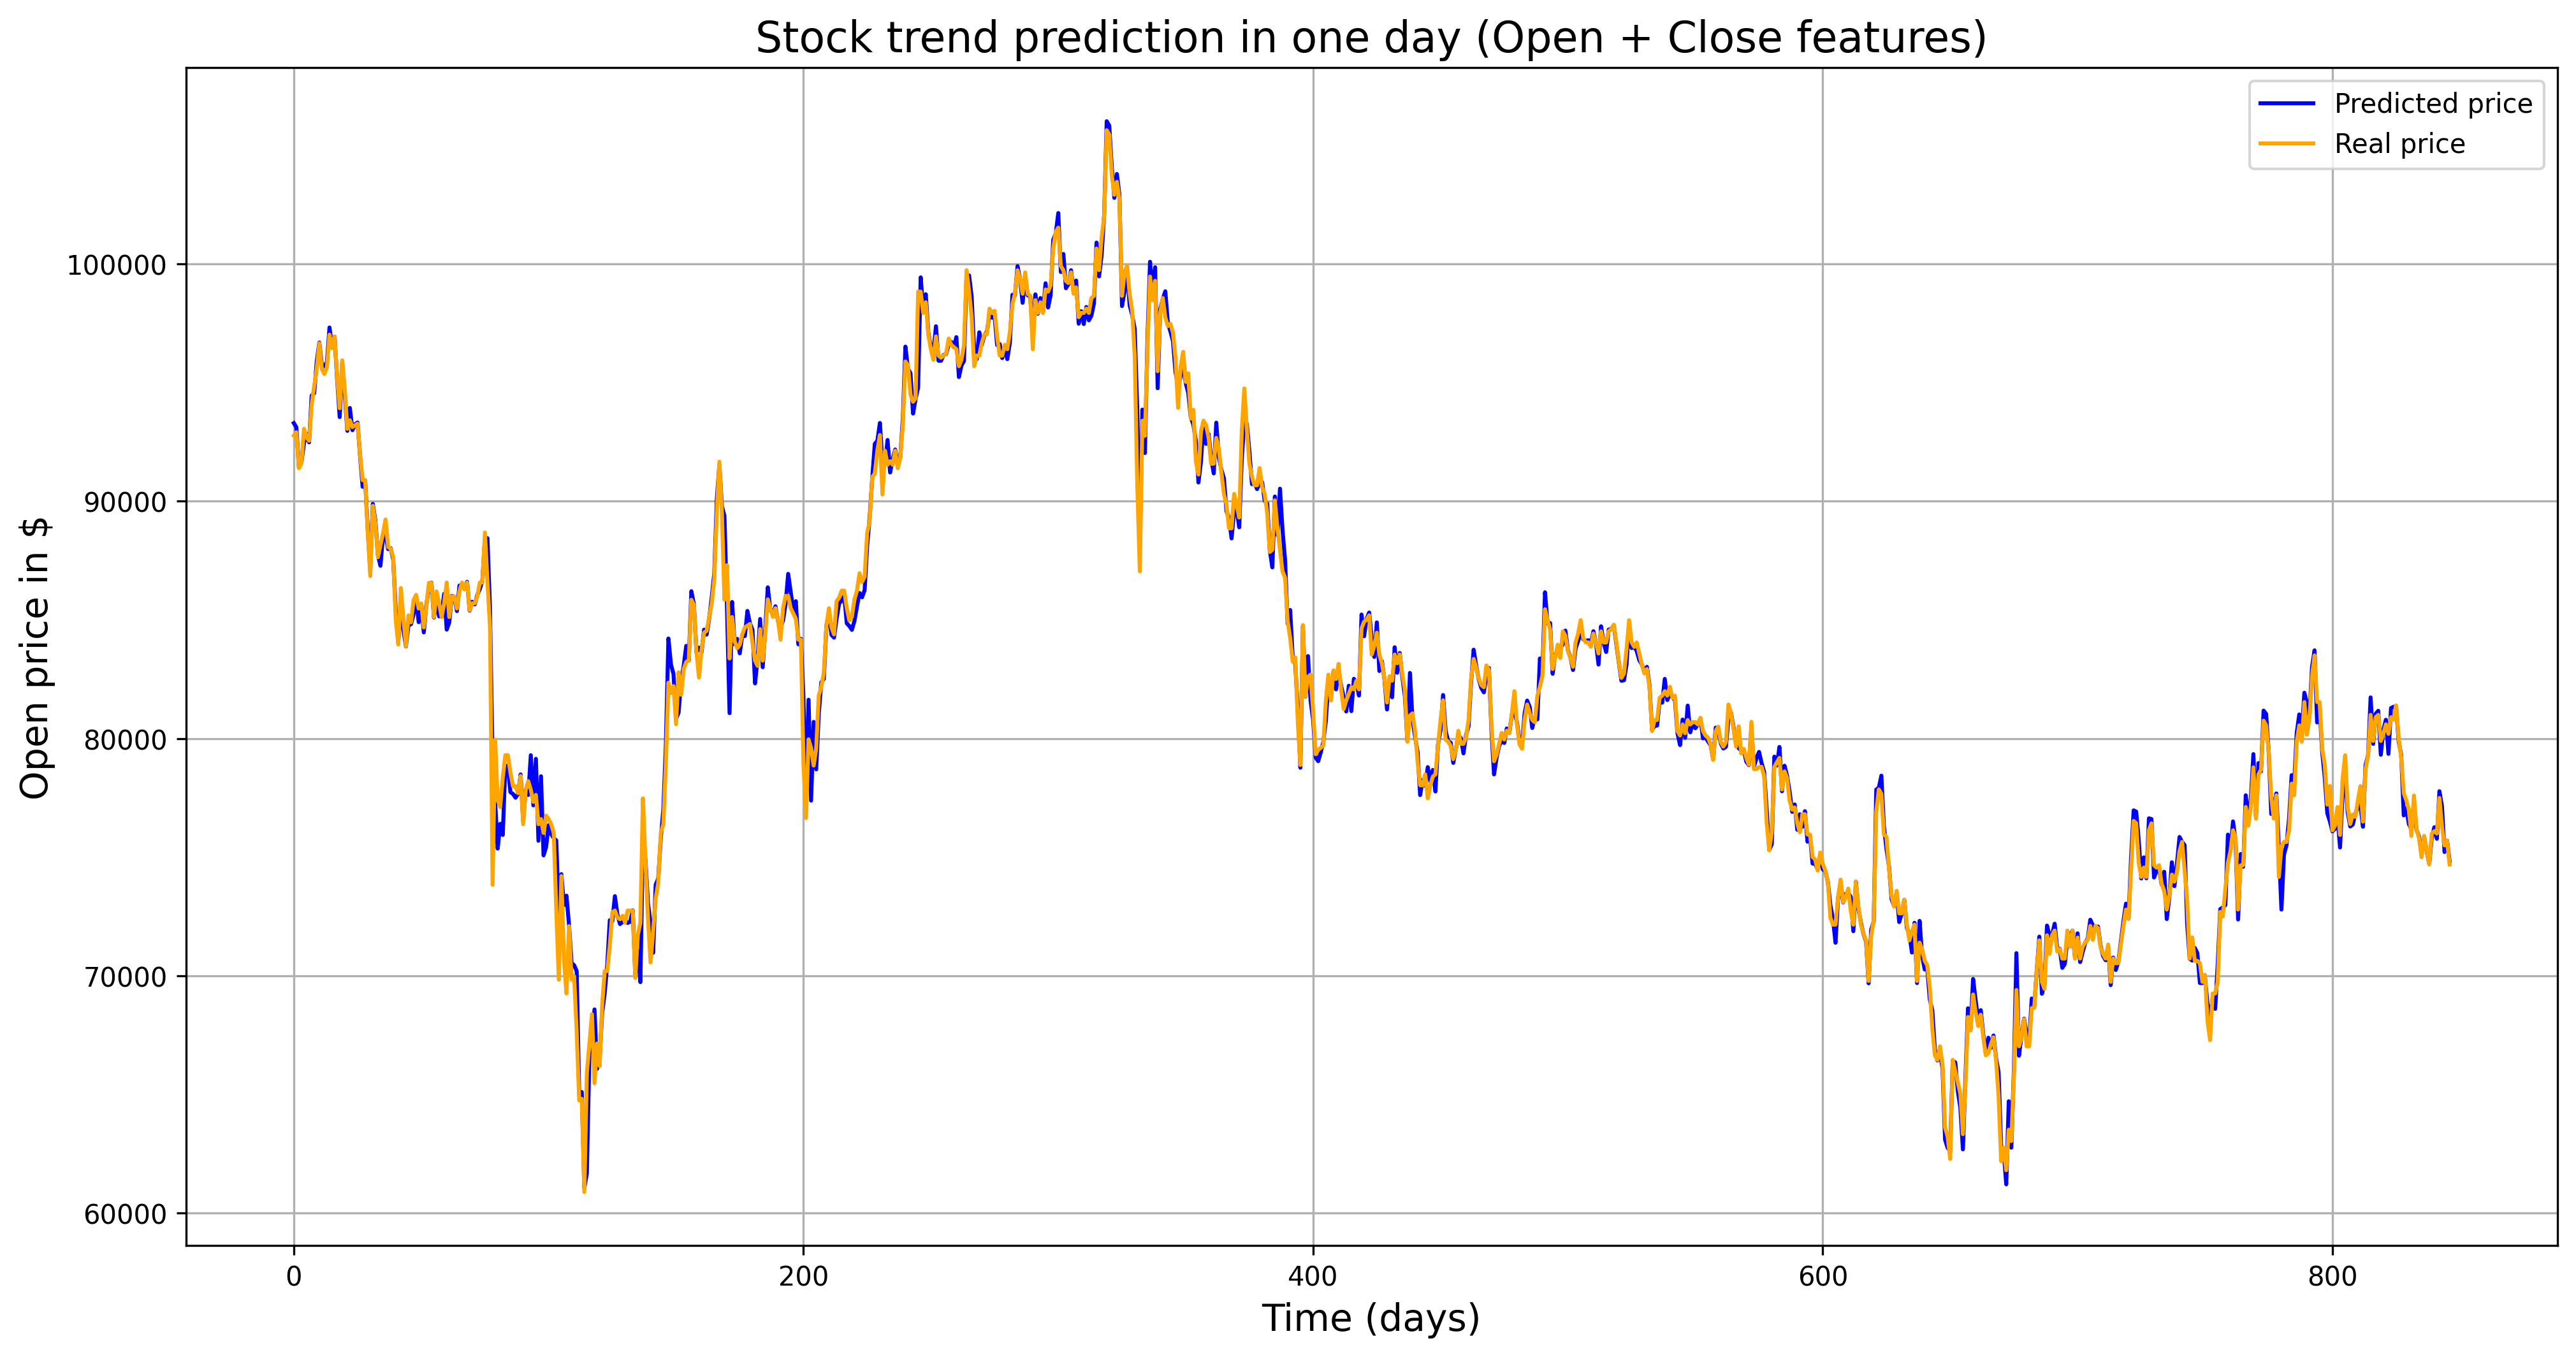

In [17]:
# Convert the result back to stock price (de-normalization) for visualization
# denorm_x = norm_x * (max - min) + min
y_pred_denorm = y_pred_norm.copy()
for i in range(len(y_pred_denorm)):
    y_pred_denorm[i] = y_pred_norm[i] * (test_maxs[i] - test_mins[i]) + test_mins[i]

# Visualize predicted stock price versus real stock price
plt.figure(figsize=(16, 8), dpi=300)
plt.plot(y_pred_denorm, label='Predicted price', color='blue')
plt.plot(y_test,        label='Real price', color='orange')
plt.title('Stock trend prediction in one day (Open + Close features)', fontsize=16)
plt.xlabel('Time (days)', fontsize=14)
plt.ylabel('Open price in $', fontsize=14)
plt.grid()
plt.legend()
plt.show()

Predict k days

In [18]:
X_datav2 = []
y_datav2 = []
  #finding the position (index) of the 'Open' column inside dataset => return 2
low_col = df.columns.get_loc('Low')
high_col = df.columns.get_loc('High')
n_features = 4  # Open + Close

In [19]:
for i in range(1, len(df) - window_size - 3):   #training dataset now has different range
    data_featurev2 = []

    # Get a window_size time frame for data features (Open and Close)
    for j in range(window_size):  #i as starting position of the window while j as offset inside the window (0 → 29)
        low_price = df.iloc[i + j, low_col]
        high_price = df.iloc[i + j, high_col]
        open_price  = df.iloc[i + j, open_col]  #i as starting position of the window while j as offset inside the window (0 → 29)
        close_price = df.iloc[i + j, close_col]
        data_featurev2.append([open_price, close_price, low_price, high_price])  #store as data feature

    # Label: predict 4th day's Open price
    data_labelv2 = [df.iloc[i + 3 + window_size, open_col]]

    # Append new data sample (feature and label) to X_data and y_data
    X_datav2.append(np.array(data_featurev2).reshape(window_size, n_features))
    #Convert data_feature (30 pairs open_close price) into Numpy array then reshap to (30, 2)
    y_datav2.append(np.array(data_labelv2))
    #Convert labels into numpy array, shape becomes (1,)

In [20]:
X_trainv2, X_testv2, y_trainv2, y_testv2 = train_test_split(X_datav2, y_datav2, test_size=0.2, shuffle=False)
X_trainv2, X_valv2, y_trainv2, y_valv2   = train_test_split(X_trainv2, y_trainv2, test_size=0.2, shuffle=False)

X_trainv2 = np.array(X_trainv2)
X_valv2   = np.array(X_valv2)
X_testv2  = np.array(X_testv2)
y_trainv2 = np.array(y_trainv2)
y_valv2   = np.array(y_valv2)
y_testv2  = np.array(y_testv2)


In [21]:
# MinMax normalize the new y data using the same mins/maxs from their corresponding X windows

X_train_norm_v2, y_train_norm_v2, _, _           = minmax_normalize(X_trainv2, y_trainv2)
X_val_norm_v2,   y_val_norm_v2,   _, _           = minmax_normalize(X_valv2,   y_valv2)
X_test_norm_v2,  y_test_norm_v2, test_minsv2, test_maxsv2 = minmax_normalize(X_testv2, y_testv2)


print("Shape of training set x: ",   X_train_norm_v2.shape)
print("Shape of traininf set y: ", y_train_norm_v2.shape)

Shape of training set x:  (2707, 30, 4)
Shape of traininf set y:  (2707, 1)


In [22]:
def augment_volatile_windows(X_norm, y_norm, n_copies=5, scale_range=(2, 5)):
    X_aug, y_aug = [X_norm], [y_norm]
    for _ in range(n_copies):
        scale      = np.random.uniform(*scale_range)
        mean       = X_norm.mean(axis=1, keepdims=True)
        X_volatile = mean + (X_norm - mean) * scale
        X_aug.append(X_volatile)
        # y is now (samples, 3)
        y_aug.append(1.0 + (y_norm - 1.0) * scale)
    return np.concatenate(X_aug), np.concatenate(y_aug)

In [23]:
X_aug, y_aug = augment_volatile_windows(X_train_norm_v2, y_train_norm_v2)

In [24]:
# Reshape to (samples, window_size, n_features=4)
X_aug = X_aug.reshape(X_aug.shape[0], window_size, n_features)
X_val_norm_v2   = X_val_norm_v2.reshape(X_val_norm_v2.shape[0],   window_size, n_features)
X_test_norm_v2  = X_test_norm_v2.reshape(X_test_norm_v2.shape[0],  window_size, n_features)

In [25]:
print("Shape of training set X: ",   X_aug.shape)
print("Shape of training set y: ", y_aug.shape)
## Final shape: (samples * 4, window, features)  ← 4x your original data

Shape of training set X:  (16242, 30, 4)
Shape of training set y:  (16242, 1)


In [26]:
def asymmetric_mse(alpha=2.0):
    def loss(y_true, y_pred):
        residual = y_true - y_pred
        # When residual > 0: model underpredicited → apply alpha penalty
        # When residual < 0: model overpredicted → normal penalty
        weight = tf.where(residual > 0, alpha, 1.0)
        return tf.reduce_mean(weight * tf.square(residual))
    return loss

In [27]:
# Define window_size and n_features explicitly within this cell
window_size = 30
n_features = 4

# Function to build the model with a given learning rate and Huber delta
def build_model(learning_rate, window_size, n_features):
    modelv2 = Sequential()
    modelv2.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=(window_size, n_features), padding='same'))
    modelv2.add(MaxPooling1D(pool_size=2))
    modelv2.add(GRU(64, return_sequences=True))
    modelv2.add(GRU(32))
    modelv2.add(Dense(32, activation='relu'))
    modelv2.add(Dense(1))
    modelv2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=asymmetric_mse(alpha=2.0),
                  metrics=['mse'])
    return modelv2

In [28]:
# Define hyperparameters to tune
learning_rates = [0.001, 0.0005]
batch_sizes = [32, 64]
epochs_list = [25, 50] # Maximum epochs, EarlyStopping will stop earlier if no improvement

best_val_loss = float('inf')
best_hps = {}
best_model_found = None

# Setup callbacks for each training run
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=0.000001)


for lr in learning_rates:
    for bs in batch_sizes:
        for ep in epochs_list:
                print(f"\n--- Training with LR: {lr}, Batch Size: {bs}, Max Epochs: {ep}")
                current_model = build_model(lr, window_size, n_features)
                history = current_model.fit(
                    X_aug, y_aug,
                    validation_data=(X_val_norm_v2, y_val_norm_v2),
                    epochs=ep,
                    batch_size=bs,
                    callbacks=[early_stopping, reduce_lr],
                    verbose=0 # suppress output for each epoch
                )

                # Get the best validation loss from this run
                val_loss = min(history.history['val_loss'])

                print(f"Validation Loss for this run: {val_loss}")

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_hps = {'learning_rate': lr, 'batch_size': bs, 'epochs': ep}
                    best_model_found = current_model # Store the model with best weights
                    print(f"New best found! Best Val Loss: {best_val_loss}, HPs: {best_hps}")

print("\n--- Tuning Complete ---")
print(f"Best Validation Loss: {best_val_loss}")
print(f"Best Hyperparameters: {best_hps}")

# Assign the best model found to modelv2 for further use
modelv2 = best_model_found
if modelv2 is not None:
    print("Best model found during tuning has been assigned to 'modelv2'.")
else:
    print("No best model was found. 'modelv2' remains unchanged.")


--- Training with LR: 0.001, Batch Size: 32, Max Epochs: 25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Validation Loss for this run: 0.10879542678594589
New best found! Best Val Loss: 0.10879542678594589, HPs: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 25}

--- Training with LR: 0.001, Batch Size: 32, Max Epochs: 50
Validation Loss for this run: 0.10753140598535538
New best found! Best Val Loss: 0.10753140598535538, HPs: {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 50}

--- Training with LR: 0.001, Batch Size: 64, Max Epochs: 25
Validation Loss for this run: 0.10758928209543228

--- Training with LR: 0.001, Batch Size: 64, Max Epochs: 50
Validation Loss for this run: 0.10888482630252838

--- Training with LR: 0.0005, Batch Size: 32, Max Epochs: 25
Validation Loss for this run: 0.10647332668304443
New best found! Best Val Loss: 0.10647332668304443, HPs: {'learning_rate': 0.0005, 'batch_size': 32, 'epochs': 25}

--- Training with LR: 0.0005, Batch Size: 32, Max Epochs: 50
Validation Loss for this run: 0.10815781354904175

--- Training with LR: 0.0005, Batch Size: 64, Max

In [29]:
static_model_weights = modelv2.get_weights()  # snapshot of tuned model

def walk_forward_predict(model, X_test, y_test, X_aug, y_aug,
                          retrain_every=30, finetune_epochs=5,
                          finetune_batch_size=32):
    predictions = []
    n_test      = len(X_test)

    for i in range(0, n_test, retrain_every):
        # ── 1. Predict current chunk BEFORE retraining ────────────
        chunk_X = X_test[i : i + retrain_every]
        chunk_preds = model.predict(chunk_X, verbose=0)
        predictions.extend(chunk_preds.flatten())
        print(f"Chunk {i}–{min(i+retrain_every, n_test)}: predicted {len(chunk_preds)} samples")

        # ── 2. Fine-tune on everything seen so far ────────────────
        if i > 0:
            X_seen = X_test[:i]                 # past test inputs  (no leak)
            y_seen = y_test[:i]                 # past test labels  (no leak)

            # Combine augmented train + real test data seen so far
            X_finetune = np.concatenate([X_aug,   X_seen])
            y_finetune = np.concatenate([y_aug,   y_seen])

            model.fit(
                X_finetune, y_finetune,
                epochs=finetune_epochs,         # short fine-tune
                batch_size=finetune_batch_size,
                verbose=0
            )
            print(f"  → Fine-tuned on {len(X_finetune)} samples "
                  f"({len(X_aug)} aug + {len(X_seen)} seen test)")

    return np.array(predictions[:n_test])


In [30]:
wf_predictions_norm = walk_forward_predict(
    model              = modelv2,
    X_test             = X_test_norm_v2,
    y_test             = y_test_norm_v2,
    X_aug              = X_aug,
    y_aug              = y_aug,
    retrain_every      = 30,   # tune: smaller = adapts faster, slower to run
    finetune_epochs    = 5,    # tune: more = learns more, risks forgetting
    finetune_batch_size= 32
)


Chunk 0–30: predicted 30 samples
Chunk 30–60: predicted 30 samples
  → Fine-tuned on 16272 samples (16242 aug + 30 seen test)
Chunk 60–90: predicted 30 samples
  → Fine-tuned on 16302 samples (16242 aug + 60 seen test)
Chunk 90–120: predicted 30 samples
  → Fine-tuned on 16332 samples (16242 aug + 90 seen test)
Chunk 120–150: predicted 30 samples
  → Fine-tuned on 16362 samples (16242 aug + 120 seen test)
Chunk 150–180: predicted 30 samples
  → Fine-tuned on 16392 samples (16242 aug + 150 seen test)
Chunk 180–210: predicted 30 samples
  → Fine-tuned on 16422 samples (16242 aug + 180 seen test)
Chunk 210–240: predicted 30 samples
  → Fine-tuned on 16452 samples (16242 aug + 210 seen test)
Chunk 240–270: predicted 30 samples
  → Fine-tuned on 16482 samples (16242 aug + 240 seen test)
Chunk 270–300: predicted 30 samples
  → Fine-tuned on 16512 samples (16242 aug + 270 seen test)
Chunk 300–330: predicted 30 samples
  → Fine-tuned on 16542 samples (16242 aug + 300 seen test)
Chunk 330–360: 

In [31]:
print("MSE on the test set (normalized): ", mean_squared_error(wf_predictions_norm, y_test_norm_v2))

MSE on the test set (normalized):  0.10568203295407011


In [32]:
wf_predictions_raw = (wf_predictions_norm * (test_maxsv2 - test_minsv2)) + test_minsv2

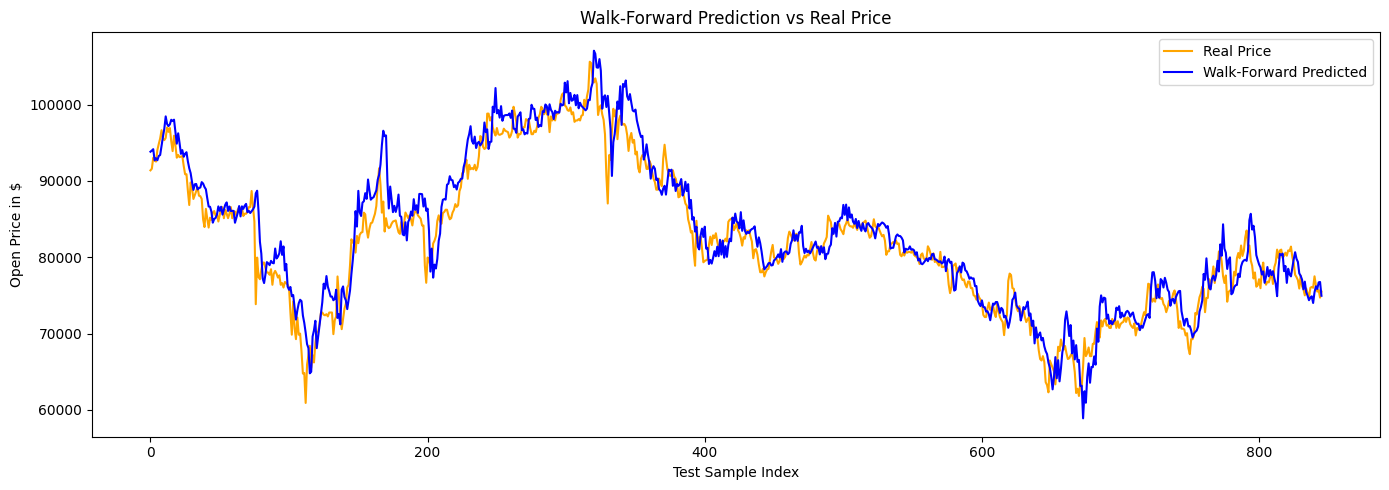

In [33]:
plt.figure(figsize=(14, 5))
plt.plot(y_testv2,          label='Real Price',            color='orange')
plt.plot(wf_predictions_raw,  label='Walk-Forward Predicted', color='blue')
plt.title('Walk-Forward Prediction vs Real Price')
plt.xlabel('Test Sample Index')
plt.ylabel('Open Price in $')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Check actual volatility ratio between train and test
train_vol = X_train_norm_v2.std(axis=1).mean()
test_vol  = X_test_norm_v2.std(axis=1).mean()
ratio = test_vol / train_vol

print(f"Train vol: {train_vol:.4f}")
print(f"Test vol:  {test_vol:.4f}")
print(f"Ratio:     {ratio:.2f}x")

Train vol: 0.2270
Test vol:  0.2206
Ratio:     0.97x


Predict 3 days ahead

In [35]:
n_ahead     = 3
X_datav3, y_datav3 = [], []

for i in range(1, len(df) - window_size - n_ahead):
    data_featurev3 = []
    for j in range(window_size):
        open_price  = df.iloc[i + j, open_col]
        close_price = df.iloc[i + j, close_col]
        low_price   = df.iloc[i + j, low_col]
        high_price  = df.iloc[i + j, high_col]
        data_featurev3.append([open_price, close_price, low_price, high_price])

    #Collect all 3 future labels

    data_labelv3 = [
        df.iloc[i + window_size + 1, open_col],   # day+1
        df.iloc[i + window_size + 2, open_col],   # day+2
        df.iloc[i + window_size + 3, open_col],   # day+3
    ]

    X_datav3.append(np.array(data_featurev3).reshape(window_size, n_features))
    y_datav3.append(np.array(data_labelv3))        # shape: (3,)

In [36]:
X_trainv3, X_testv3, y_trainv3, y_testv3 = train_test_split(X_datav3, y_datav3, test_size=0.2, shuffle=False)
X_trainv3, X_valv3, y_trainv3, y_valv3   = train_test_split(X_trainv3, y_trainv3, test_size=0.2, shuffle=False)

In [37]:
X_trainv3 = np.array(X_trainv3)
X_valv3  = np.array(X_valv3)
X_testv3  = np.array(X_testv3)
y_trainv3 = np.array(y_trainv3)   # shape: (samples, 3)
y_valv3   = np.array(y_valv3)
y_testv3  = np.array(y_testv3)

In [38]:
X_train_norm_v3, y_train_norm_v3, _, _                      = minmax_normalize(X_trainv3, y_trainv3)
X_val_norm_v3,   y_val_norm_v3,   _, _                      = minmax_normalize(X_valv3,   y_valv3)
X_test_norm_v3,  y_test_norm_v3,  test_minsv3, test_maxsv3  = minmax_normalize(X_testv3,  y_testv3)

X_train_norm_v3 = X_train_norm_v3.reshape(X_train_norm_v3.shape[0], window_size, n_features)
X_val_norm_v3   = X_val_norm_v3.reshape(X_val_norm_v3.shape[0],     window_size, n_features)
X_test_norm_v3  = X_test_norm_v3.reshape(X_test_norm_v3.shape[0],   window_size, n_features)

In [39]:
def build_model_v3(learning_rate, window_size, n_features, n_ahead):

    modelv3 = Sequential([
        Conv1D(64, kernel_size=3, activation='relu',
               input_shape=(window_size, n_features), padding='same'),
        MaxPooling1D(pool_size=2),
        GRU(64, return_sequences=True),
        GRU(32),
        Dense(32, activation='relu'),
        Dense(n_ahead)                 # from Dense(1) to Dense(3)
    ])
    modelv3.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=asymmetric_mse(alpha=2.0),
        metrics=['mse']
    )
    return modelv3

In [40]:
def walk_forward_predict(model, X_test, y_test, X_aug, y_aug,
                          retrain_every=30, finetune_epochs=5,
                          finetune_batch_size=32):
    predictions = []
    n_test      = len(X_test)

    for i in range(0, n_test, retrain_every):
        chunk_X     = X_test[i : i + retrain_every]
        chunk_preds = model.predict(chunk_X, verbose=0)  # shape: (chunk, 3)
        predictions.extend(chunk_preds)                  # store (chunk, 3) rows
        print(f"Chunk {i}–{min(i + retrain_every, n_test)}: "
              f"predicted {len(chunk_preds)} samples")
        if i > 0:
            X_seen     = X_test[:i]
            y_seen     = y_test[:i]
            X_finetune = np.concatenate([X_aug,  X_seen])
            y_finetune = np.concatenate([y_aug,  y_seen])
            model.fit(
                X_finetune, y_finetune,
                epochs=finetune_epochs,
                batch_size=finetune_batch_size,
                verbose=0
            )
            print(f"  → Fine-tuned on {len(X_aug)} aug + "
                  f"{len(X_seen)} seen test samples")

    predictions = np.array(predictions[:n_test])  # shape: (n_test, 3)
    return predictions


In [41]:
# Augment training data
X_aug_v3, y_aug_v3 = augment_volatile_windows(
    X_train_norm_v3, y_train_norm_v3,
    n_copies=5, scale_range=(2, 5)
)
X_aug_v3 = X_aug_v3.reshape(X_aug_v3.shape[0], window_size, n_features)

# ── Train ─────────────────────────────────────────────────────────
learning_rate = 0.001
batch_size    = 32
epochs        = 30

modelv3 = build_model_v3(learning_rate, window_size, n_features, n_ahead)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
history = modelv3.fit(
    X_aug_v3, y_aug_v3,
    validation_data=(X_val_norm_v3, y_val_norm_v3),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=15,
                      restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6)
    ],
    verbose=1
)


Epoch 1/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.7790 - mse: 0.5598 - val_loss: 0.0772 - val_mse: 0.0492 - learning_rate: 0.0010
Epoch 2/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6762 - mse: 0.4721 - val_loss: 0.0724 - val_mse: 0.0516 - learning_rate: 0.0010
Epoch 3/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.6561 - mse: 0.4567 - val_loss: 0.0774 - val_mse: 0.0486 - learning_rate: 0.0010
Epoch 4/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6425 - mse: 0.4489 - val_loss: 0.0806 - val_mse: 0.0494 - learning_rate: 0.0010
Epoch 5/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.6059 - mse: 0.4258 - val_loss: 0.0721 - val_mse: 0.0477 - learning_rate: 0.0010
Epoch 6/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.5396 - mse: 0.3885 - val_loss: 0.0870 - val_mse: 0.0569 - learning_rate: 0.0010
Epoch 7/30
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4338 - mse: 0.3236 - val_loss: 0.0843 - val_mse: 0.0562 - learning_rate: 0.0010
Epoch 

In [43]:
# ── Walk-forward prediction ───────────────────────────────────────
print("\nStarting walk-forward prediction...")
wf_predictions_normv3 = walk_forward_predict(
    model               = modelv3,
    X_test              = X_test_norm_v3,
    y_test              = y_test_norm_v3,
    X_aug               = X_aug_v3,
    y_aug               = y_aug_v3,
    retrain_every       = 30,
    finetune_epochs     = 5,
    finetune_batch_size = 32
)
# shape: (n_test, 3)


Starting walk-forward prediction...
Chunk 0–30: predicted 30 samples
Chunk 30–60: predicted 30 samples
  → Fine-tuned on 16242 aug + 30 seen test samples
Chunk 60–90: predicted 30 samples
  → Fine-tuned on 16242 aug + 60 seen test samples
Chunk 90–120: predicted 30 samples
  → Fine-tuned on 16242 aug + 90 seen test samples
Chunk 120–150: predicted 30 samples
  → Fine-tuned on 16242 aug + 120 seen test samples
Chunk 150–180: predicted 30 samples
  → Fine-tuned on 16242 aug + 150 seen test samples
Chunk 180–210: predicted 30 samples
  → Fine-tuned on 16242 aug + 180 seen test samples
Chunk 210–240: predicted 30 samples
  → Fine-tuned on 16242 aug + 210 seen test samples
Chunk 240–270: predicted 30 samples
  → Fine-tuned on 16242 aug + 240 seen test samples
Chunk 270–300: predicted 30 samples
  → Fine-tuned on 16242 aug + 270 seen test samples
Chunk 300–330: predicted 30 samples
  → Fine-tuned on 16242 aug + 300 seen test samples
Chunk 330–360: predicted 30 samples
  → Fine-tuned on 1624

In [44]:
# Reshape to (samples, 1) so it broadcasts across 3 day predictions
test_minsv3_r = test_minsv3.reshape(-1, 1)  # (1196, 1)
test_maxsv3_r = test_maxsv3.reshape(-1, 1)  # (1196, 1)

# Now shapes are compatible:
# predictions:  (1196, 3)
# mins/maxs:    (1196, 1) → broadcasts to (1196, 3)
wf_predictions_rawv3 = (wf_predictions_normv3 * (test_maxsv3_r - test_minsv3_r)) + test_minsv3_r
y_test_rawv3         = (y_test_norm_v3        * (test_maxsv3_r - test_minsv3_r)) + test_minsv3_r

Day+1 → MSE:3250292.3433
Day+2 → MSE:4994355.8263
Day+3 → MSE:7126237.6343


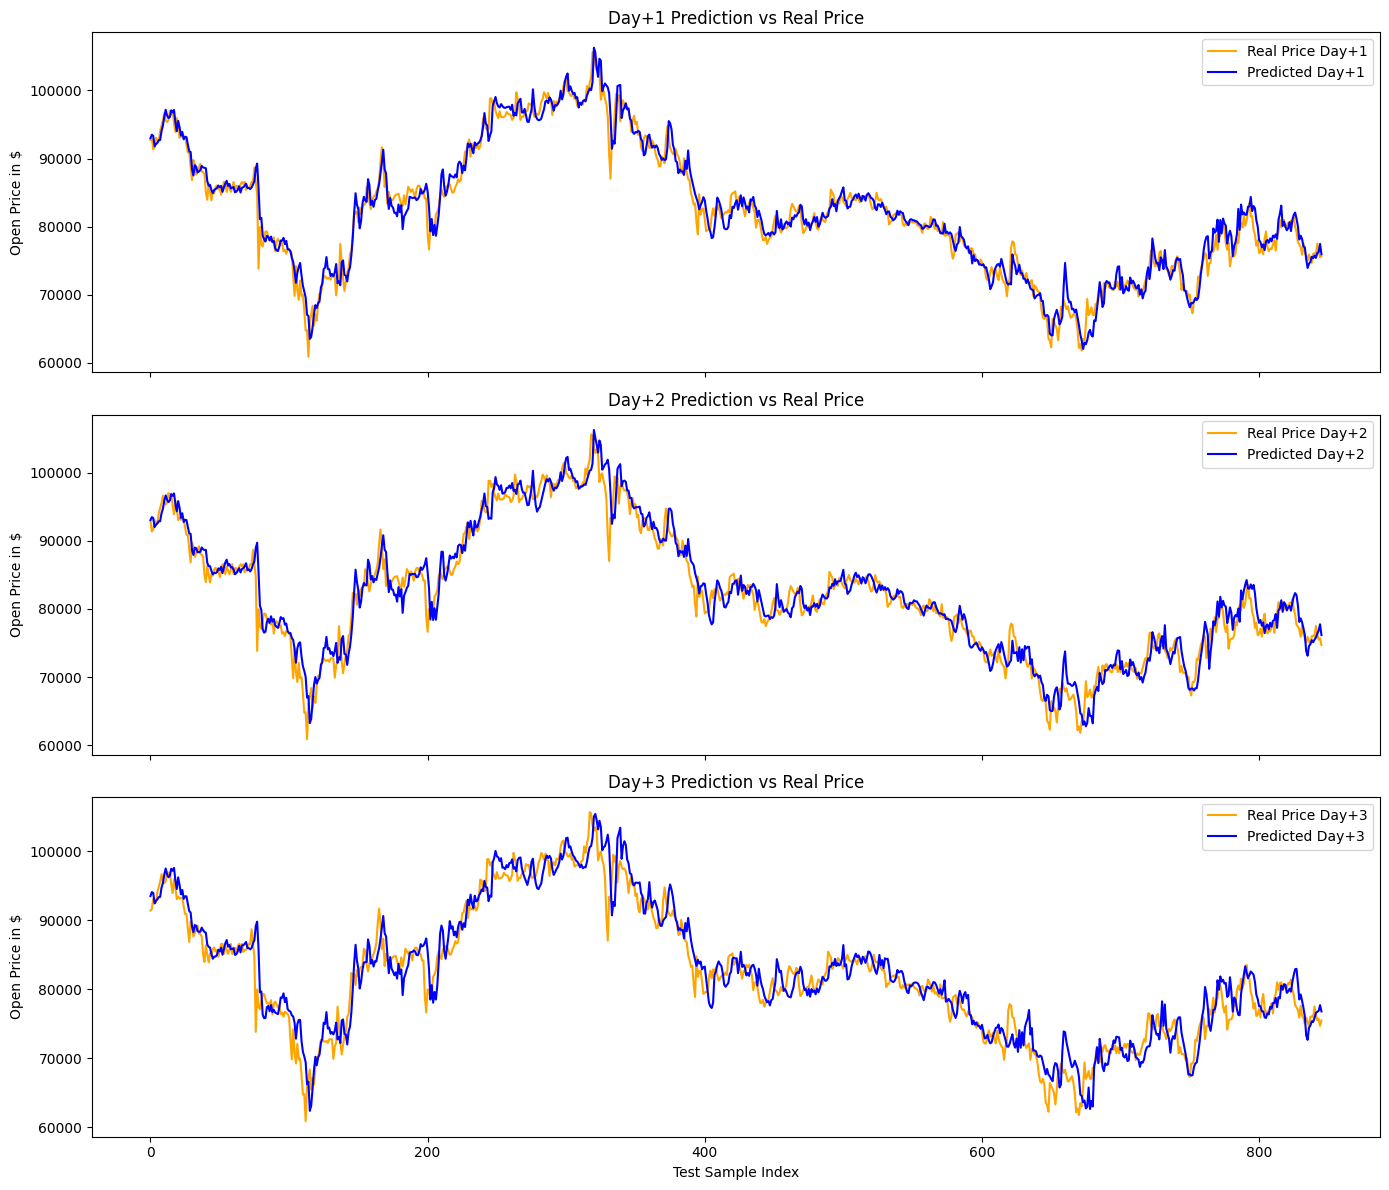

In [45]:
for day in range(n_ahead):
    mse  = np.mean((wf_predictions_rawv3[:, day] - y_test_rawv3[:, day]) ** 2)
    print(f"Day+{day+1} → MSE:{mse:.4f}")

# ── Plot all 3 horizons ───────────────────────────────────────────
fig, axes = plt.subplots(n_ahead, 1, figsize=(14, 4 * n_ahead), sharex=True)

for day in range(n_ahead):
    axes[day].plot(y_test_rawv3[:, day],
                   label=f'Real Price Day+{day+1}',  color='orange')
    axes[day].plot(wf_predictions_rawv3[:, day],
                   label=f'Predicted Day+{day+1}',   color='blue')
    axes[day].set_title(f'Day+{day+1} Prediction vs Real Price')
    axes[day].set_ylabel('Open Price in $')
    axes[day].legend()

axes[-1].set_xlabel('Test Sample Index')
plt.tight_layout()
plt.show()